In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("asaniczka/uk-optimal-product-price-prediction")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\Bruno\.cache\kagglehub\datasets\asaniczka\uk-optimal-product-price-prediction\versions\3


In [3]:
import os
file_path = os.path.join(path, "amz_uk_price_prediction_dataset.csv")
df = pd.read_csv(file_path)

In [4]:
df.head()

,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
0,1,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
1,2,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",4.7,98099,23.99,True,0,Hi-Fi Speakers
2,3,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
3,4,B09B8T5VGV,"Echo Dot with clock (5th generation, 2022 rele...",4.7,7205,31.99,False,0,Hi-Fi Speakers
4,5,B09WX6QD65,Introducing Echo Pop | Full sound compact Wi-F...,4.6,1881,17.99,False,0,Hi-Fi Speakers


In [5]:
df.shape

(2443651, 9)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2443651 entries, 0 to 2443650
Data columns (total 9 columns):
 #   Column             Dtype  
---  ------             -----  
 0   uid                int64  
 1   asin               object 
 2   title              object 
 3   stars              float64
 4   reviews            int64  
 5   price              float64
 6   isBestSeller       bool   
 7   boughtInLastMonth  int64  
 8   category           object 
dtypes: bool(1), float64(2), int64(3), object(3)
memory usage: 151.5+ MB


In [7]:
df.isna().sum()

uid                  0
asin                 0
title                0
stars                0
reviews              0
price                0
isBestSeller         0
boughtInLastMonth    0
category             0
dtype: int64

### Part 1: Understanding Product Categories

**Business Question**: What are the most popular product categories on Amazon UK, and how do they compare in terms of listing frequency?

1. **Frequency Tables**:
    - Generate a frequency table for the product `category`.
    - Which are the top 5 most listed product categories?

In [8]:
category_frequency_table = df["category"].value_counts()
category_frequency_table

category
Sports & Outdoors                         836265
Beauty                                     19312
Handmade Clothing, Shoes & Accessories     19229
Bath & Body                                19092
Birthday Gifts                             18978
                                           ...  
Alexa Built-In Devices                       107
Motorbike Chassis                            107
Plugs                                        107
Smart Home Security & Lighting               104
Smart Speakers                                54
Name: count, Length: 296, dtype: int64

In [9]:
category_frequency_table.shape

(296,)

In [10]:
top_5_category = category_frequency_table.iloc[0:5]
top_5_category

category
Sports & Outdoors                         836265
Beauty                                     19312
Handmade Clothing, Shoes & Accessories     19229
Bath & Body                                19092
Birthday Gifts                             18978
Name: count, dtype: int64

In [11]:
type(top_5_category)

pandas.core.series.Series

In [12]:
top_5_category.index

Index(['Sports & Outdoors', 'Beauty', 'Handmade Clothing, Shoes & Accessories',
       'Bath & Body', 'Birthday Gifts'],
      dtype='object', name='category')

The top 5 most listed product categories are "Sports & Outdoors", "Beauty", "Handmade Clothing, Shoes & Accessories", "Bath & Body", and "Birthday Gifts".

2. **Visualizations**:
    - Display the distribution of products across different categories using a bar chart. *If you face problems understanding the chart, do it for a subset of top categories.*
    - For a subset of top categories, visualize their proportions using a pie chart. Does any category dominate the listings?

C:\Users\Bruno\AppData\Local\Temp\ipykernel_2332\381206614.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


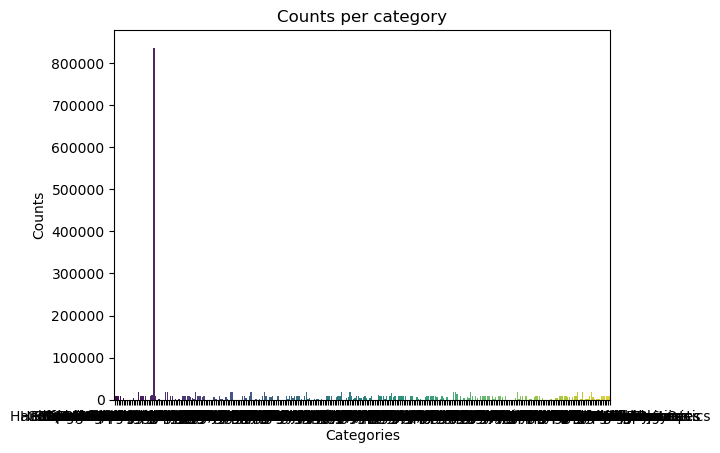

In [38]:
sns.countplot(
    x="category",
    data=df,
    palette='viridis',
    legend=False,
)
plt.xlabel("Categories")
plt.ylabel("Counts")
plt.title("Counts per category")
plt.show()

Considering the large number of categories, this countplot is dificult to interpret. Hence, a plot for a subset of categories (top5 based on counts) will be created.

In [14]:
df2 = pd.DataFrame(top_5_category)
df2

,count
category,
Sports & Outdoors,836265
Beauty,19312
"Handmade Clothing, Shoes & Accessories",19229
Bath & Body,19092
Birthday Gifts,18978


In [15]:
type(df2)

pandas.core.frame.DataFrame

C:\Users\Bruno\AppData\Local\Temp\ipykernel_2332\2366775427.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


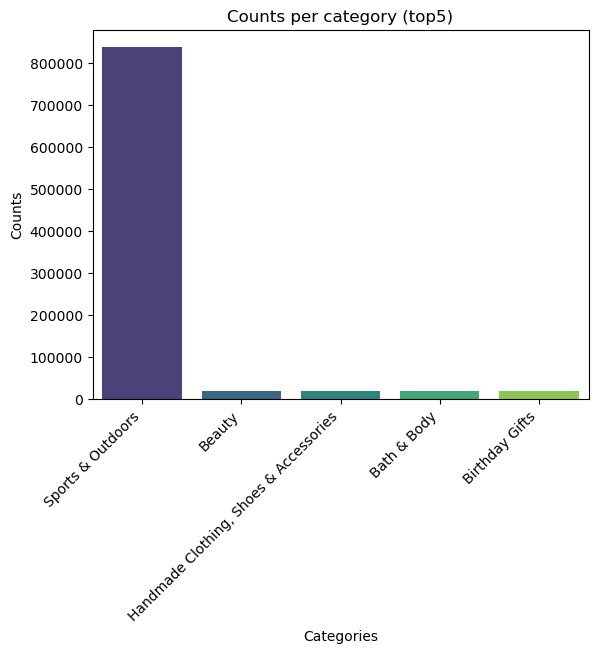

In [39]:
sns.barplot(
    x="category",
    y='count',
    data=df2,
    palette='viridis',
    legend=True,
)
plt.xlabel("Categories")
plt.ylabel("Counts")
plt.title("Counts per category (top5)")
plt.xticks(rotation=45, ha='right')
plt.show()

This barplot shows that the category Sports & Outdoors clearly dominates the listings in Amazon UK.

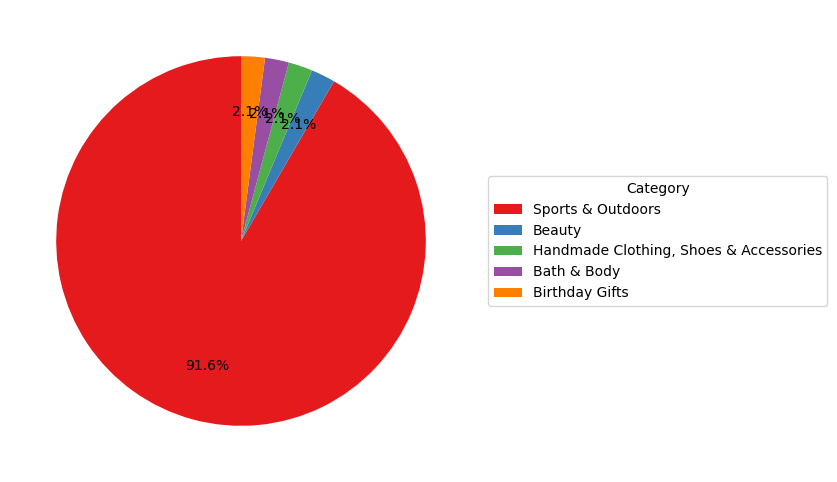

In [52]:
fig, ax = plt.subplots(figsize=(9, 6))
top_5_category.plot.pie(autopct='%1.1f%%' ,startangle=90, colors=sns.color_palette('Set1'), labels=None, pctdistance=0.7, textprops={"fontsize":10}, ax=ax)
ax.set_ylabel('')  
ax.legend(
    top_5_category.index,
    title='Category',
    loc='center left',
    bbox_to_anchor=(1.02, 0.5)
)
plt.show()

Again, as observed in the bar plot, the Sports & Outdoors category dominates Amazon UK's listings.

### Part 2: Delving into Product Pricing

**Business Question**: How are products priced on Amazon UK, and are there specific price points or ranges that are more common?

1. **Measures of Centrality**:
    - Calculate the mean, median, and mode for the `price` of products.
    - What's the average price point of products listed? How does this compare with the most common price point (mode)?

In [18]:
df.head()

,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
0,1,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
1,2,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",4.7,98099,23.99,True,0,Hi-Fi Speakers
2,3,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
3,4,B09B8T5VGV,"Echo Dot with clock (5th generation, 2022 rele...",4.7,7205,31.99,False,0,Hi-Fi Speakers
4,5,B09WX6QD65,Introducing Echo Pop | Full sound compact Wi-F...,4.6,1881,17.99,False,0,Hi-Fi Speakers


In [19]:
df.describe()

,uid,stars,reviews,price,boughtInLastMonth
count,2.443651e+06,2.443651e+06,2.443651e+06,2.443651e+06,2.443651e+06
mean,1.370545e+06,2.152836e+00,4.806278e+02,8.924381e+01,2.589699e+01
std,8.160562e+05,2.194865e+00,5.944124e+03,3.456089e+02,2.404837e+02
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,6.589215e+05,0.000000e+00,0.000000e+00,9.990000e+00,0.000000e+00
50%,1.349029e+06,0.000000e+00,0.000000e+00,1.909000e+01,0.000000e+00
75%,2.060686e+06,4.400000e+00,5.900000e+01,4.599000e+01,0.000000e+00
max,2.828593e+06,5.000000e+00,1.356658e+06,1.000000e+05,5.000000e+04


In [20]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
uid,2443651.0,1.370545e+06,816056.169852,1.0,658921.50,1349029.00,2060685.50,2828593.0
stars,2443651.0,2.152836e+00,2.194865,0.0,0.00,0.00,4.40,5.0
reviews,2443651.0,4.806278e+02,5944.124151,0.0,0.00,0.00,59.00,1356658.0
price,2443651.0,8.924381e+01,345.608862,0.0,9.99,19.09,45.99,100000.0
boughtInLastMonth,2443651.0,2.589699e+01,240.483727,0.0,0.00,0.00,0.00,50000.0


In [44]:
price_mean = round(df["price"].mean(), 2)
price_median = df["price"].median()
price_mode = df["price"].mode()

print(f"The mean price is {price_mean}£.")
print(f"The median price is {price_median}£.")
print(f"The mode price is {float(price_mode)}£.")

The mean price is 89.24£.
The median price is 19.09£.
The mode price is 9.99£.


C:\Users\Bruno\AppData\Local\Temp\ipykernel_2332\3117257279.py:7: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  print(f"The mode price is {float(price_mode)}£.")


The mean price is significantly higher than the median and the mode, which indicates a positive skew. This is caused by a small number of items that have a very large price.

2. **Measures of Dispersion**:
    - Determine the variance, standard deviation, range, and interquartile range for product `price`.
    - How varied are the product prices? Are there any indicators of a significant spread in prices?

In [22]:
price_std = round(df["price"].std(), 2)
price_var = round(df["price"].var(), 2)
price_quartile_25 = np.quantile(df["price"], 0.25)
price_quartile_75 = np.quantile(df["price"], 0.75)
price_interquartile_range = price_quartile_75 - price_quartile_25

print(f"The standard deviation of price is {price_std}£.")
print(f"The variance of price is {price_var}£.")
print(f"The first quartile price is {price_quartile_25}£.")
print(f"The third quartile price is {price_quartile_75}£.")
print(f"The interquartile range of price is {price_interquartile_range}£.")

The standard deviation of price is 345.61£.
The variance of price is 119445.49£.
The first quartile price is 9.99£.
The third quartile price is 45.99£.
The interquartile range of price is 36.0£.


The standard deviation of prices is significantly higher than the mean, which indicates high variability.
However, 50% os listings fall within a range of 36.0£, which is a short range, that indicates that there are listings with values far from the average.

3. **Visualizations**:
    - Is there a specific price range where most products fall? Plot a histogram to visualize the distribution of product prices. *If its hard to read these diagrams, think why this is, and explain how it could be solved.*.
    - Are there products that are priced significantly higher than the rest? Use a box plot to showcase the spread and potential outliers in product pricing. 

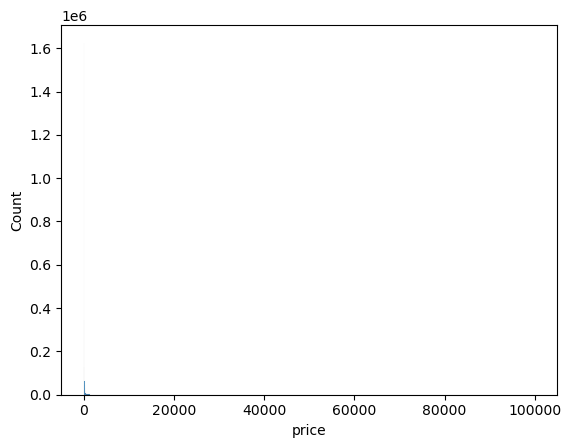

In [23]:
sns.histplot(df["price"], bins="auto")
plt.show()

In [24]:
len(df["price"].unique())

82916

This histogram is difficult to read since there are 82916 different prices and a positive skew, indicating the bulk of values are on the left size of the axis (lower prices).

To solve this, is we really want to use a histogram we could use a log scale in the x-axis. Otherwise, we could do a boxplot.

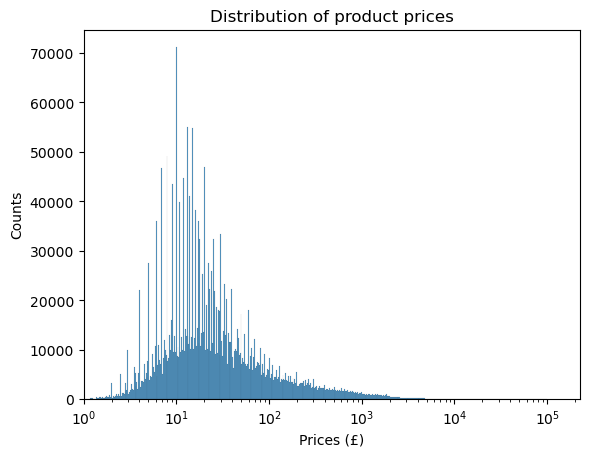

In [54]:
sns.histplot(df["price"], bins="auto", log_scale=True)
plt.xlim(1,)
plt.xlabel("Prices (£)")
plt.ylabel("Counts")
plt.title("Distribution of product prices")
plt.show()

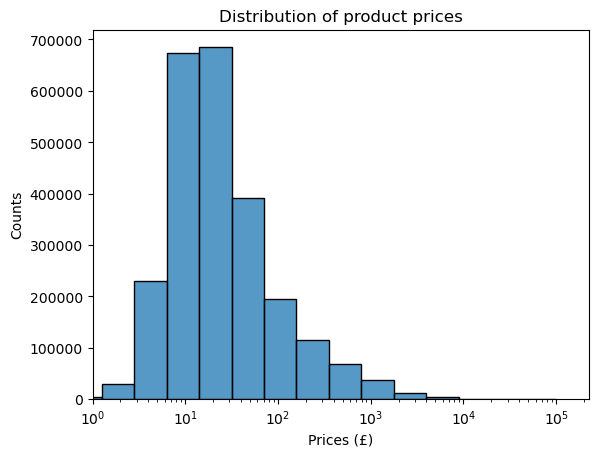

In [55]:
sns.histplot(df["price"], bins=20, log_scale=True)
plt.xlim(1,)
plt.xlabel("Prices (£)")
plt.ylabel("Counts")
plt.title("Distribution of product prices")
plt.show()

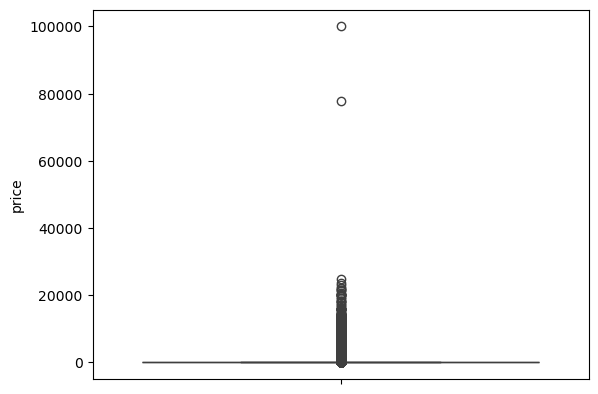

In [27]:
sns.boxplot(df["price"])
plt.show()

As observed in the boxplot, there are listings which are clear outliers, with the prices falling way above the remaining listings.

### Part 3: Unpacking Product Ratings

**Business Question**: How do customers rate products on Amazon UK, and are there any patterns or tendencies in the ratings?

1. **Measures of Centrality**:
    - Calculate the mean, median, and mode for the `rating` of products.
    - How do customers generally rate products? Is there a common trend?

In [28]:
df.head()

,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
0,1,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
1,2,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",4.7,98099,23.99,True,0,Hi-Fi Speakers
2,3,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
3,4,B09B8T5VGV,"Echo Dot with clock (5th generation, 2022 rele...",4.7,7205,31.99,False,0,Hi-Fi Speakers
4,5,B09WX6QD65,Introducing Echo Pop | Full sound compact Wi-F...,4.6,1881,17.99,False,0,Hi-Fi Speakers


In [29]:
df["stars"].isna().sum()

np.int64(0)

This shows that there are no null values in the stars column.

In [30]:
df["stars"].value_counts()

stars
0.0    1225641
4.5     151577
4.6     136995
4.4     136165
5.0     128492
4.3     112564
4.7      94566
4.2      86871
4.0      66089
4.1      65115
4.8      41858
3.9      36555
3.8      27876
3.7      21137
3.6      16219
3.5      14673
3.0      12819
4.9      11081
3.4      10355
1.0       8484
3.3       8269
3.2       5771
3.1       4679
2.0       3901
2.9       3341
2.8       2306
2.7       2104
2.5       2103
2.6       1579
2.4       1060
2.3        734
2.2        602
2.1        540
1.5        404
1.9        300
1.8        249
1.7        177
1.4        149
1.6        147
1.3         78
1.2         23
1.1          3
Name: count, dtype: int64

A rating of 0 indicates that no ratings were found. There are 1225641 listings with no ratings.

Considering these are null values, since they do not represent user ratings, the corresponding rows will be droped so the data analysis is not influenced by them.

In [31]:
df.shape

(2443651, 9)

In [56]:
df3 = df.drop(df[df["stars"] == 0.0].index)
df3 = df3.reset_index()
df3

,index,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
0,0,1,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
1,1,2,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",4.7,98099,23.99,True,0,Hi-Fi Speakers
2,2,3,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
3,3,4,B09B8T5VGV,"Echo Dot with clock (5th generation, 2022 rele...",4.7,7205,31.99,False,0,Hi-Fi Speakers
4,4,5,B09WX6QD65,Introducing Echo Pop | Full sound compact Wi-F...,4.6,1881,17.99,False,0,Hi-Fi Speakers
...,...,...,...,...,...,...,...,...,...,...
1218005,2443642,2828585,B07DCFQMQL,Speed MaxX BODY ARMOUR CE MOTORBIKE/MOTORCYCLE...,3.6,66,49.99,False,0,Motorbike Clothing
1218006,2443643,2828586,B07JM5VQFX,Motorcycle Clothing Suit - Motorbike Suit With...,4.1,5,158.99,False,0,Motorbike Clothing
1218007,2443644,2828587,B07X98JLFF,GREAT BIKERS GEAR - Bobber Cafe Brat Style Lea...,3.6,12,14.99,False,0,Motorbike Clothing
1218008,2443649,2828592,B008OYLL4I,Texpeed Mens Motorcycle Motorbike Biker Trouse...,4.3,404,79.99,False,0,Motorbike Clothing


In [57]:
rating_mean = round(df3["stars"].mean(), 2)
rating_median = df3["stars"].median()
rating_mode = df3["stars"].mode()

print(f"The mean rating is {rating_mean} stars.")
print(f"The median rating is {rating_median} stars.")
print(f"The mode rating is {float(rating_mode)} stars.")

The mean rating is 4.32 stars.
The median rating is 4.4 stars.
The mode rating is 4.5 stars.


C:\Users\Bruno\AppData\Local\Temp\ipykernel_2332\499812699.py:7: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  print(f"The mode rating is {float(rating_mode)} stars.")


Customers tend to rate the listing high, and both the median and mode are close the the mean.

2. **Measures of Dispersion**:
    - Determine the variance, standard deviation, and interquartile range for product `rating`.
    - Are the ratings consistent, or is there a wide variation in customer feedback?

In [34]:
rating_std = round(df3["stars"].std(), 2)
rating_var = round(df3["stars"].var(), 2)
rating_quartile_25 = np.quantile(df3["stars"], 0.25)
rating_quartile_75 = np.quantile(df3["stars"], 0.75)
rating_interquartile_range = rating_quartile_75 - rating_quartile_25

print(f"The standard deviation of rating is {rating_std} stars.")
print(f"The variance of rating is {rating_var} stars.")
print(f"The first quartile rating is {rating_quartile_25} stars.")
print(f"The third quartile rating is {rating_quartile_75} stars.")
print(f"The interquartile range of rating is {rating_interquartile_range} stars.")

The standard deviation of rating is 0.56 stars.
The variance of rating is 0.31 stars.
The first quartile rating is 4.1 stars.
The third quartile rating is 4.6 stars.
The interquartile range of rating is 0.5 stars.


The ratings are consistent among listings, with 50% of values comprised between 4.1 and 4.6 stars, showing low variation in customer feedback.

3. **Shape of the Distribution**:
    - Calculate the skewness and kurtosis for the `rating` column. 
    - Are the ratings normally distributed, or do they lean towards higher or lower values?

In [59]:
round(float(df3["stars"].skew()), 2)

-2.38

The negative skew indicates the distribution is left skewed, indicating the bulk of data is on the right side (high ratings), but there are some low ratings that skew the results.

In [60]:
round(float(df3["stars"].kurtosis()), 2)

9.78

A kurtosis value > 3.0 indicates a leptokurtic distribution.

4. **Visualizations**:
    - Plot a histogram to visualize the distribution of product ratings. Is there a specific rating that is more common?

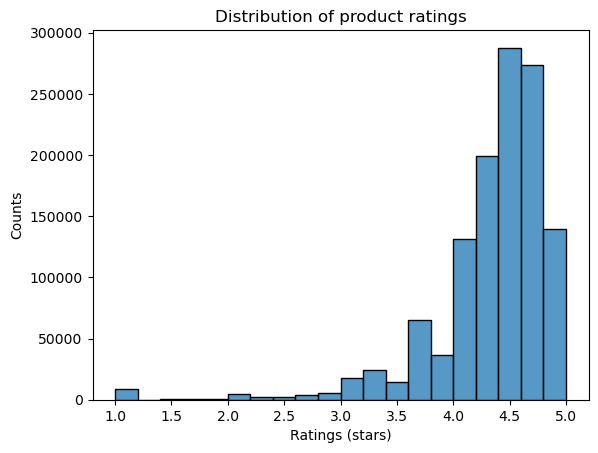

In [61]:
sns.histplot(df3["stars"], bins=20)
plt.xlabel("Ratings (stars)")
plt.ylabel("Counts")
plt.title("Distribution of product ratings")
plt.show()

As demonstrated before by the distribution parameters, we can observe a left skew in the distribution.

Histograms shows ranges, not specific values, so we can't assess if there is a more common rating with this graph type.

However, we can observe that ratings from 4.0 to 5.0 are the most common.

In [62]:
df3["stars"].value_counts()

stars
4.5    151577
4.6    136995
4.4    136165
5.0    128492
4.3    112564
4.7     94566
4.2     86871
4.0     66089
4.1     65115
4.8     41858
3.9     36555
3.8     27876
3.7     21137
3.6     16219
3.5     14673
3.0     12819
4.9     11081
3.4     10355
1.0      8484
3.3      8269
3.2      5771
3.1      4679
2.0      3901
2.9      3341
2.8      2306
2.7      2104
2.5      2103
2.6      1579
2.4      1060
2.3       734
2.2       602
2.1       540
1.5       404
1.9       300
1.8       249
1.7       177
1.4       149
1.6       147
1.3        78
1.2        23
1.1         3
Name: count, dtype: int64

With the frequency table it is possible to observe that the rating of 4.5 stars is the most common.